In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import warnings
from sklearn.model_selection import KFold
from scipy import stats

import utils.model_fitting as fit
from utils.stats_perform import *
from utils.plots import *
from utils.data import *
from utils.path import PathConfig,FigureWithData

seed_value = 1234  # Or any integer you like
np.random.seed(seed_value)
random.seed(seed_value)
warnings.filterwarnings("ignore")


fig_dir = os.path.join('figures', 'figure_4')
data_fig_dir = os.path.join('data', 'source_data', 'figure_4')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)


## Habenula lesion data analysis

This notebook performs the  analysis of the Habenula lesion dataset performed in the manuscript:  *Romero Pinto, S., & Uchida, N. (2023). **Tonic dopamine and biases in value learning linked through a biologically inspired reinforcement learning model***

The dataset consists of electrophysiological recordgins of VTA dopamine neurons and the behavioral readouts  published originally in *Habenula Lesions Reveal that Multiple Mechanisms Underlie Dopamine Prediction Errors. Neuron, 87(6), 1304–1316 [https://doi.org/10.1016/j.neuron.2015.08.028*]

**Note:** To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [2]:
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir
col_g = ['black','red']
groups = ['control','lesion']
nf = [45,44]
probs_cues = [10,50,90]
s = dict()
s['baselineWindow']      = [-1500, -500]  #% in units of milliseconds
s['psthWindow']          = [-1500, 4500]  #% in units of milliseconds
s['cueWindow']           = [0, 400]   # in units of milliseconds
s['traceWindow']         = [500, 2000]  #% in units of milliseconds
s['outcomeWindow']       = [2000, 2600] # % in units of milliseconds
s['outcomeWindowLate']       = [2200, 2600]  #% in units of milliseconds
s['outcomeWindowFreeLate']   = [200, 400]  #% in units of milliseconds
s['psthResolution']          = 2   #% in units of milliseconds
s['normalizeTo50']           = True # % when true, this will normalize the 50% responses for each cell according to the mean (across cells) of 50% responses in that animal.
s['smoothingTimeConst']      = 20;  #% 20 is what the eshel paper used (units of milliseconds)
s['interestingTrialTypes']   = np.arange(15)
s['maxTrialsPerType'] = 300
s['indeces'] = dict()
s['indeces']['puff80'] = [6,7]
s['indeces']['prob10']= [4,5]
s['indeces']['prob50'] = [2,3]
s['indeces']['prob90']= [0,1]
s['indeces']['freeRew'] = 8
s['indeces']['freePuff'] = 9
alpha_p = .05

loader_c = DataLoad(s)
data_path = os.path.join(g_dir, 'raw_data',groups[0])
data_path
file_list = glob.glob(data_path + '/*.pickle')
PSTH, PSTC, spikeRaster = loader_c.load_cells(file_list,response_type = 'spikes')
print('computing responses for '+ groups[0])
loader_c.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_c.load_cells(file_list,response_type = 'licks')
_,_,_ =loader_c.compute_lick_responses(PSTH_licks)
loader_c.get_cells_same_day(file_list)

loader_l= DataLoad(s)
data_path = os.path.join(g_dir,'raw_data', groups[1])
file_list = glob.glob(data_path + '/*.pickle')
PSTH, PSTC, spikeRaster = loader_l.load_cells(file_list,response_type = 'spikes')
loader_l.compute_responses_re_baseline(PSTH)
PSTH_licks, PSTC_licks, lickRaster = loader_l.load_cells(file_list,response_type = 'licks')
_,_,_=loader_l.compute_lick_responses(PSTH_licks)
loader_l.get_cells_same_day(file_list)

Cell Number: 100%|██████████| 45/45 [00:12<00:00,  3.67it/s]


computing responses for control


Cell Number: 100%|██████████| 44/44 [00:06<00:00,  7.08it/s]


### Figure 4b
- Trace responses licks
- Trace responses licks (normalized)


The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_4/figure_4b_leftpanel.pdf
Saved data and stats to data/source_data/figure_4/figure_4b_leftpanel.txt


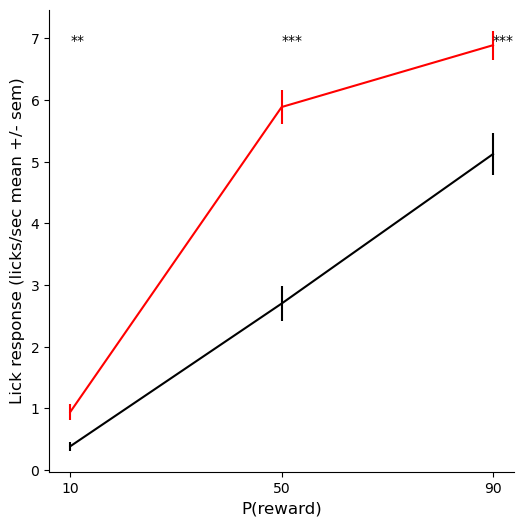

In [3]:
mu_across_cells_c,sem_across_cells_c,per_cell_c = loader_c.compute_mu_responses_per_cue(loader_c.traceResponses_licks,idU = loader_c.idU)
mu_across_cells_l,sem_across_cells_l,per_cell_l = loader_l.compute_mu_responses_per_cue(loader_l.traceResponses_licks,idU = loader_l.idU)

groups_test = [[per_cell_c[ii,:],per_cell_l[ii,:]] for ii in range(per_cell_l.shape[0])]
name_suff = ['10','50','90']
name_preff = 'licks'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True )
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].pvals.to_numpy()[0] for ig in range(3)])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stats.to_numpy()[0] for ig in range(3)])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stat_name.to_numpy()[0] for ig in range(3)])
yy = np.max([mu_across_cells_c,mu_across_cells_l])

fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[ii],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Lick response (licks/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)

# Create the wrapper object
fig_data = FigureWithData(fig)
# Add panel data
panel_data = np.column_stack((probs_cues, mu_across_cells_c, sem_across_cells_c, mu_across_cells_l, sem_across_cells_l))
panel_headers = ['P_reward', 'Mean_Licks_CueC', 'SEM_Licks_CueC', 'Mean_Licks_CueL', 'SEM_Licks_CueL']
fig_data.add_data("Lick responses across reward probabilities", panel_data, panel_headers)
# Add stats
stat_array = np.column_stack((probs_cues, pvals, stats_p))
stat_headers = ['P_reward', 'p_value', 'test_statistic']
fig_data.add_stats("Statistical tests (ranksum per P(reward))", stat_array, stat_headers, test_names=list(stats_n))
# Save
fig_data.save( base_filename='figure_4b_leftpanel',
    folder_data=data_fig_dir,      # where txt will go
    folder_figures=fig_dir        # where pdf will go
)


The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_4/figure_4b_rightpanel.pdf
Saved data and stats to data/source_data/figure_4/figure_4b_rightpanel.txt


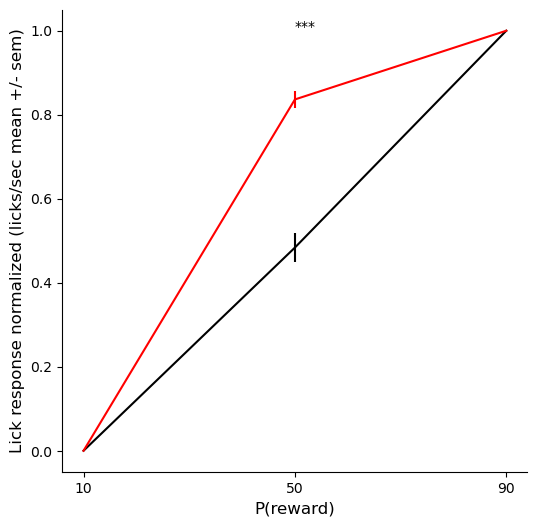

In [4]:
indeces_resp = [loader_l.indeces_prob10,loader_l.indeces_prob50,loader_l.indeces_prob90]
responses = loader_c.traceResponses_licks 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_cn = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_cn = np.nanmean(per_cell_cn,axis=2)
per_cell_cn_50 = per_cell_cn[1,~np.isnan(per_cell_cn[1,:])]
responses = loader_l.traceResponses_licks 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_ln = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_ln = np.nanmean(per_cell_ln,axis=2)
per_cell_ln_50 = per_cell_ln[1,~np.isnan(per_cell_ln[1,:])]

mu_across_cells_c,sem_across_cells_c = np.nanmean(per_cell_cn,axis=1),np.nanstd(per_cell_cn,axis=1)/np.sqrt(per_cell_cn.shape[1])
mu_across_cells_l,sem_across_cells_l = np.nanmean(per_cell_ln,axis=1),np.nanstd(per_cell_ln,axis=1)/np.sqrt(per_cell_ln.shape[1])

groups_test = [[per_cell_cn_50,per_cell_ln_50] ]
name_suff = ['50']
name_preff = 'lick_norm' 
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].pvals.to_numpy()[0] ])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] ==0)].stats.to_numpy()[0]])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].stat_name.to_numpy()[0] ])

yy = np.max([mu_across_cells_c,mu_across_cells_l])
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[1],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Lick response normalized (licks/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)


# 1. Create the wrapper
fig_data = FigureWithData(fig)

# 2. Add the mean lick response data
panel_data = np.column_stack((
    probs_cues,
    mu_across_cells_c,
    sem_across_cells_c,
    mu_across_cells_l,
    sem_across_cells_l
))
panel_headers = ['P_reward', 'Mean_Licks_CueC', 'SEM_Licks_CueC', 'Mean_Licks_CueL', 'SEM_Licks_CueL']
fig_data.add_data("Lick responses normalized across reward probabilities", panel_data, panel_headers)

# 3. Add the stats
stat_array = np.column_stack((probs_cues[1], pvals, stats_p))
stat_headers = ['P_reward', 'p_value', 'test_statistic']
fig_data.add_stats("Statistical test (ranksum, reward 50%)", stat_array, stat_headers, test_names=list(stats_n))

# 4. Save
fig_data.save(
    base_filename='figure_4b_rightpanel',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)


### Figure 4d 
- Cue responses raw
- Cue responses normalized

The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_4/figure_4d_leftpanel.pdf
Saved data and stats to data/source_data/figure_4/figure_4d_leftpanel.txt


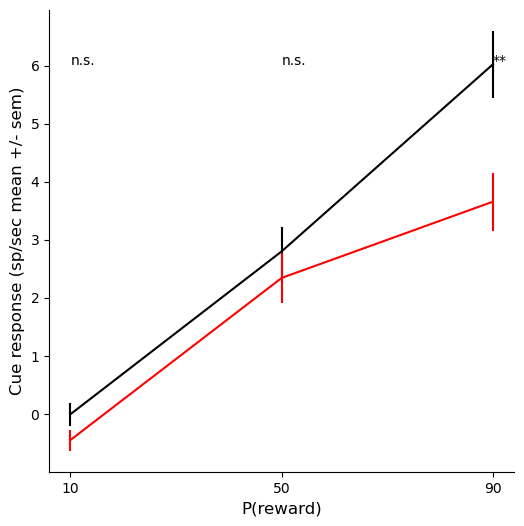

In [5]:

mu_across_cells_c,sem_across_cells_c,per_cell_c = loader_c.compute_mu_responses_per_cue(loader_c.cueResponses)
mu_across_cells_l,sem_across_cells_l,per_cell_l = loader_l.compute_mu_responses_per_cue(loader_l.cueResponses)
alpha_p = .05
groups_test = [[per_cell_c[ii,:],per_cell_l[ii,:]] for ii in range(per_cell_l.shape[0])]
name_suff = ['10','50','90']
name_preff = 'cue_raw'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd,alpha_p=alpha_p)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].pvals.to_numpy()[0] for ig in range(3)])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stats.to_numpy()[0] for ig in range(3)])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == ig)].stat_name.to_numpy()[0] for ig in range(3)])
yy = np.max([mu_across_cells_c,mu_across_cells_l])
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[ii],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Cue response (sp/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)

# 1. Create the wrapper
fig_data_4d_left = FigureWithData(fig)

# 2. Add panel data
panel_data = np.column_stack((
    probs_cues,
    mu_across_cells_c,
    sem_across_cells_c,
    mu_across_cells_l,
    sem_across_cells_l
))
panel_headers = ['P_reward', 'Mean_CueResponse_C', 'SEM_CueResponse_C', 'Mean_CueResponse_L', 'SEM_CueResponse_L']
fig_data_4d_left.add_data("Cue responses (raw) across reward probabilities", panel_data, panel_headers)

# 3. Add stats
stat_array = np.column_stack((probs_cues, pvals, stats_p))
stat_headers = ['P_reward', 'p_value', 'test_statistic']
fig_data_4d_left.add_stats("Statistical tests (ranksum per reward prob)", stat_array, stat_headers, test_names=list(stats_n))

# 4. Save
fig_data_4d_left.save(
    base_filename='figure_4d_leftpanel',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)



The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_4/figure_4d_rightpanel.pdf
Saved data and stats to data/source_data/figure_4/figure_4d_rightpanel.txt


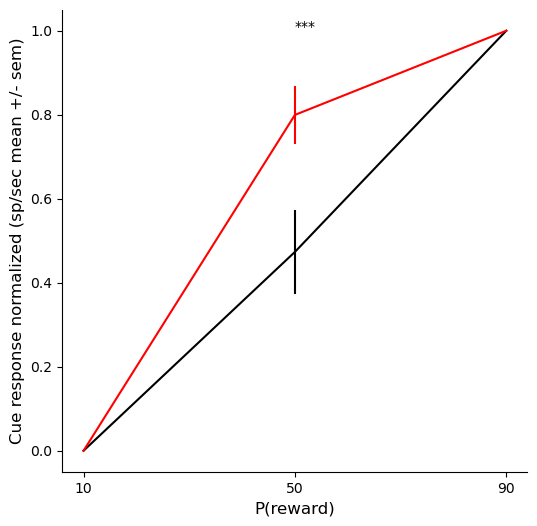

In [6]:
indeces_resp = [loader_l.indeces_prob10,loader_l.indeces_prob50,loader_l.indeces_prob90]
responses = loader_l.cueResponses 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_ln = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_ln = np.nanmean(per_cell_ln,axis=2)

responses = loader_c.cueResponses 
per_cell = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
per_cell_cn = (per_cell - np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])/(np.nanmean(per_cell[2,:,:],axis=1)[np.newaxis,:,np.newaxis]-np.nanmean(per_cell[0,:,:],axis=1)[np.newaxis,:,np.newaxis])
per_cell_cn = np.nanmean(per_cell_cn,axis=2)
mu_across_cells_c,sem_across_cells_c = np.nanmean(per_cell_cn,axis=1),np.nanstd(per_cell_cn,axis=1)/np.sqrt(per_cell_cn.shape[1])
mu_across_cells_l,sem_across_cells_l = np.nanmean(per_cell_ln,axis=1),np.nanstd(per_cell_ln,axis=1)/np.sqrt(per_cell_ln.shape[1])

alpha_p = .05
groups_test = [[per_cell_cn[1,:],per_cell_ln[1,:]] ]
name_suff = ['50']
name_preff = 'cue_norm' 
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd)
pvals = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].pvals.to_numpy()[0] ])
stats_p = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] ==0)].stats.to_numpy()[0]])
stats_n = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_nb'] == 0)].stat_name.to_numpy()[0] ])

yy = np.max([mu_across_cells_c,mu_across_cells_l])
fig,ax = plt.subplots(figsize=(6,6))
ax.errorbar(probs_cues,mu_across_cells_c,sem_across_cells_c,color=col_g[0])
ax.errorbar(probs_cues,mu_across_cells_l,sem_across_cells_l,color=col_g[1])
[ax.text(probs_cues[1],yy,get_pval_str(pv)) for (ii,pv) in enumerate(pvals)]
plot_config(ax,'P(reward)','Cue response normalized (sp/sec mean +/- sem)',12,False)
ax.set_xticks(probs_cues)

# 1. Create the wrapper
fig_data_4d_right = FigureWithData(fig)

# 2. Add panel data
panel_data = np.column_stack((
    probs_cues,
    mu_across_cells_c,
    sem_across_cells_c,
    mu_across_cells_l,
    sem_across_cells_l
))
panel_headers = ['P_reward', 'Mean_CueResponseNorm_C', 'SEM_CueResponseNorm_C', 'Mean_CueResponseNorm_L', 'SEM_CueResponseNorm_L']
fig_data_4d_right.add_data("Cue responses (normalized) across reward probabilities", panel_data, panel_headers)

# 3. Add stats (only one pval/statistic)
stat_array = np.column_stack((probs_cues[1], pvals, stats_p))
stat_headers = ['P_reward', 'p_value', 'test_statistic']
fig_data_4d_right.add_stats("Statistical test (ranksum, reward 50%)", stat_array, stat_headers, test_names=list(stats_n))

# 4. Save
fig_data_4d_right.save(
    base_filename='figure_4d_rightpanel',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)




### Figure 4c
Model fits to anticipatory licking 

## Fit RL models to behavior

This notebook performs fits of RL models to the behavioral anticipatory licking responses from the Habenula lesion dataset  

The code below fits 3 different RL models to the licking data on a trial by trial basis: 

**Symmetric** :

$V \leftarrow V + \alpha \cdot \delta \\$ 
$\delta = r - V\\$
$\text{licks} = \beta \cdot V$

parameters: $\theta = \{\beta, \alpha \}$

**Reward sensitivity** 

$V \leftarrow V + \alpha \cdot \delta \\$ 
$\delta =\rho \cdot r - V\\$
$\text{licks} = \beta \cdot V$

parameters: $\theta = \{\beta, \alpha, \rho\}$

**Asymmetric** 

$V \leftarrow V + \tau \cdot \delta ~~~~~ \text{if} ~\delta>0\\$ 
$V \leftarrow V +(1-\tau) \cdot \delta ~~~~~ \text{if} ~\delta<0\\$ 
$\delta =r - V\\$
$\text{licks} = \beta \cdot V$

parameters: $\theta = \{\beta, \tau\}$

**Note**:To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.

In [7]:
# Sandra Romero Pinto 2022, based  on Sam Gershman, June 2015
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir
suffs = ['control','lesion']
tr_win = [500, 2000]
psth_resolution = 10
e_values = [.5,.5,.5,.5]#[.9,.5,.1,-.8]
map_= [0,0,1,1,2,2,3,3]
psth_length = np.intp( 1 + np.ceil((tr_win[1] - tr_win[0]) / psth_resolution) )
alpha_p = .05
mice_v,mice_all,dates_all, id_unique_,u_dates_ = get_mice_dates_list(g_dir,suffs)
u_max = np.max([len(ii) for ii in id_unique_])

models = [ 'asymmetric']
results_groups = dict(zip(suffs,[dict() for i in range(len(suffs))]))
id_sim_ = []
for suffix , i_suff in zip(suffs, range(len(suffs))):
    for model in models:
        results_groups[suffix][model]=[]        
        data_path = os.path.join(g_dir,'raw_data',  suffix)
        ff = glob.glob(data_path + "/*.pickle")
        id_unique = id_unique_[i_suff]
        id_sim = []
        print('RL Fitting for group ' + suffix + '|| Model ' + model )
        for iff in tqdm(np.arange(len(id_unique)),'subject:'):
            idu = id_unique[iff]
            with open(ff[idu], 'rb') as handle:
                unit = pickle.load(handle)
            trial_types = unit['data']['TrialTypes']
            licks =  unit['data']['responses']['lick']
            odor_on = unit['data']['events']['odorOn']
            rew_on = unit['data']['events']['rewardOn']
            puff_on = unit['data']['events']['airpuffOn']
            rew_types = map_rewards(rew_on, puff_on,trial_types)
            cue_types = map_cues(map_,trial_types)
            lick_mu , ids_keep = load_lick_raster(licks,odor_on,trial_types,tr_win,psth_resolution,psth_length)
            cue_types = cue_types[ids_keep]
            rew_types = rew_types[ids_keep]
            if np.sum(lick_mu)>0:
                lick_mu = lick_mu[np.arange(len(ids_keep))]
                ids_keep = np.arange(len(ids_keep))
                train, test = KFold(n_splits=2).split(ids_keep)
                id_train, id_test = train[1], train[0]

                data  = dict()
                data['N'] = len(id_train)
                data['c'] = cue_types[id_train]
                data['r'] = rew_types[id_train]
                data['v'] = lick_mu[id_train]
                data['trial'] = np.arange(len(id_train))
                data['v0'] = e_values

                data_test  = dict()
                data_test['N'] = len(id_test)
                data_test['c'] = cue_types[id_test]
                data_test['r'] = rew_types[id_test]
                data_test['v'] = lick_mu[id_test]
                data_test['trial'] = np.arange(len(id_test))
                data_test['v0'] = e_values

                param = fit.create_param_opt(model)
                _llfun = fit.likfun
                results = fit.rlfit_optimize(_llfun, param, data, nstarts=10)
                xx = results['x']
                lf, yhat = fit.likfun_full(xx,data_test,model)
                results['y_test'] = data_test['v']
                results['c_test'] = data_test['c']
                results['r_test'] = data_test['r']
                results['y_hat'] = yhat
                results['corr_pred'] = np.corrcoef(yhat,data_test['v'])[0,1]

                log_p_predict = fit.rlfit_predict(data_test,results,model)
                results['log_predictive_prob'] = log_p_predict
                results_groups[suffix][model].append(results)
                id_sim.append(id_unique[iff])
        id_sim_.append(id_sim)

# Fill in full arrays
results_groups_full = dict(zip(suffs,[dict() for i in range(len(suffs))]))
for suffix , i_suff in zip(suffs, range(len(suffs))):
    dates_full = dates_all[i_suff]
    results_groups_full[suffix] = dict(zip(models,[dict() for i in range(len(models))]))
    for model in models:
        results = results_groups[suffix][model]
        results_groups_full[suffix][model] = [[]]*len(dates_full)
        for (iu,ir) in  enumerate(results):
            date_ = u_dates_[i_suff][iu]
            id_fill = np.argwhere([str(id)==date_ for id in dates_full]).flatten()
            for ii in id_fill:
                results_groups_full[suffix][model][ii] = ir


RL Fitting for group control|| Model asymmetric


subject:: 100%|██████████| 35/35 [00:17<00:00,  1.98it/s]


RL Fitting for group lesion|| Model asymmetric


subject:: 100%|██████████| 30/30 [00:13<00:00,  2.25it/s]


The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_4/figure_4c_asymmetric.pdf
Saved data and stats to data/source_data/figure_4/figure_4c_asymmetric.txt


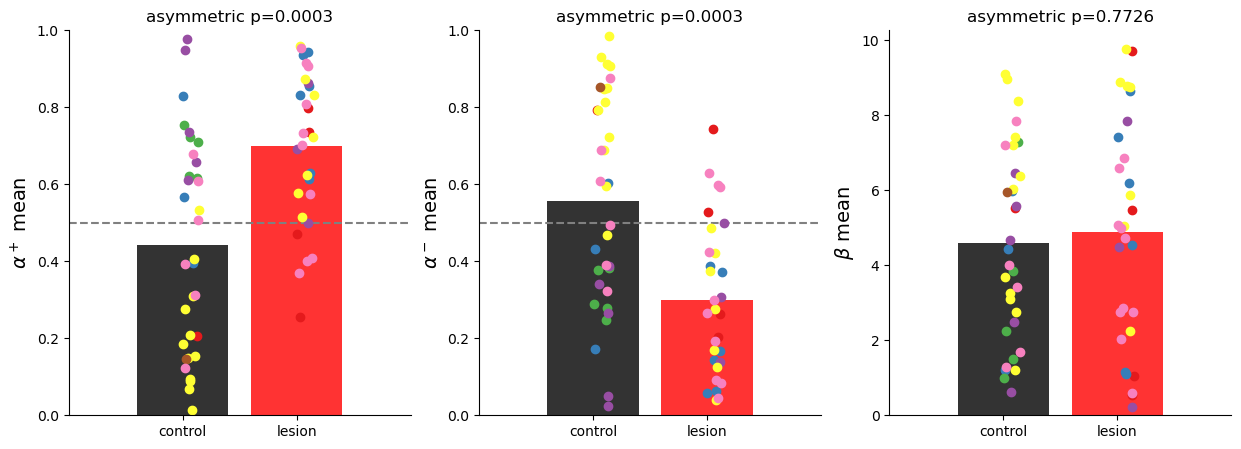

In [8]:

ylims_ = [[0.,1.],[0,2.],[0.,1.]]
cg = ['black','red']
param_names =[[r'$\alpha^+$',  r'$\alpha^-$',r'$\beta$']]
param_suff =[['alpha_pos',  'alpha_neg','beta']]

for (imod,model) in enumerate(models):
    params,params_m = [],[]    
    param_name = param_names[imod]
    for suffix , i_suff in zip(suffs, range(len(suffs))):
        params_ = []
        n_sessions = len( results_groups[suffix][model])
        id_unique,id_sim = id_unique_[i_suff],id_sim_[i_suff]
        ids = np.argwhere([sum(id_sim==iu) for iu in id_unique]).flatten()
        mice_ = mice_v[i_suff][ids]
        for iff in np.arange(n_sessions):
            if model =='asymmetric':
                x_ = results_groups[suffix][model][iff]['x']
                taus_ = x_[0]/(x_[0]+x_[1])
                params_.append(np.asarray([taus_,1-taus_,x_[2]]))
            else:
                params_.append(results_groups[suffix][model][iff]['x'])
        params_ = np.asarray(params_)
        params_per_m = [np.array([params_[ii] for ii in np.argwhere(mice_==im)]).squeeze() for im in np.unique(mice_)]
        nsess = np.asarray([len(np.argwhere(mice_==im)) for im in np.unique(mice_)])
        params_corr = [ip[np.newaxis,:] for ip in params_per_m if len(ip.shape)==1 ]
        for (iid,ii) in enumerate(np.argwhere(nsess==1).flatten()):
            params_per_m[ii] = params_corr[iid]
        params.append(params_)
        params_m.append(params_per_m)
    n_params = params[0].shape[1]

    groups_test = [[params[0][:,jj],params[1][:,jj]]  for jj in np.arange(n_params)]
    name_suff = param_suff[imod]
    name_preff = model
    # if imod ==0:
        # tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = True,alpha_p=alpha_p)
    # else:
    tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False, tests_pd=tests_pd,alpha_p=alpha_p)
    pvals_norm = np.asarray([tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == model + '_all')].pvals.to_numpy()[0]  ])
    
    ll = len(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == model+'_all' )].pvals.to_numpy()[0])
    ss = np.sum(tests_pd[(tests_pd['name_test'] == 'normaltest') & (tests_pd['group_name'] == model+'_all' )].pvals.to_numpy()[0]>.05)
    if ll>ss:
        st = np.asarray([tests_pd[(tests_pd['name_test'] == 'ranksum') & (tests_pd['group_name'] == model + '_'+ isuff)].pvals.to_numpy()[0] for isuff in name_suff])
    else:
        st = np.asarray([tests_pd[(tests_pd['name_test'] == 'ttest') & (tests_pd['group_name'] == model + '_'+ isuff)].pvals.to_numpy()[0] for isuff in name_suff])
    if np.sum(pvals_norm<alpha_p) ==2:
        mus_ = np.asarray([np.nanmedian(x[:,ii]) for x in params for ii in np.arange(n_params)])
        ylab = 'median'
    else:
        mus_ = np.asarray([np.nanmean(x[:,ii]) for x in params for ii in np.arange(n_params)])
        ylab = 'mean'

    fix,ax  = plt.subplots(1,n_params,figsize=(5*n_params,5))    
    if n_params==1:  ax = np.asarray(ax)[...,np.newaxis]
    id_lims = ['alpha' in ip for ip in param_name]
    [ax[ii].plot([-1,2],[.5,.5],color='grey',linestyle='--') for ii in np.argwhere(id_lims).flatten()]
    [ax[ii].bar(np.arange(2),mus_[np.arange(ii,len(mus_),step=n_params)],color=cg,alpha=.8) for ii in np.arange(n_params)]
    [[[ax[ii].plot(ix+.15*np.random.rand(len(np.asarray(iparamsuff[im])[:,ii])),np.asarray(iparamsuff[im])[:,ii],'o',color=cm.Set1(im/len(iparamsuff))) for ii in range(n_params)] for im in range(len(iparamsuff))] for  (ix,iparamsuff) in enumerate(params_m)] 
    [plot_config(ax[ii],'',param_name[ii] + ' '+ylab,14,False) for ii in np.arange(n_params)]
    [ax[ii].set_xlim(([-1,2])) for ii in np.arange(n_params)]
    [ax[ii].set_ylim([0.,1.]) for ii in np.argwhere(id_lims).flatten()]
    [ax[ii].set_xticks([0,1]) for ii in np.arange(n_params)]
    [ax[ii].set_xticklabels(suffs) for ii in np.arange(n_params)]
    [ax[ii].set_title(model+' p='+str(np.round(st[ii]*10000)/10000)) for ii in np.arange(n_params)]


    # After creating fig, ax for this model

    fig_data_4c_model = FigureWithData(fix)  # your fig is called 'fix'

    # Group averages (for bar plots)
    mus_grouped = mus_.reshape(2, -1)  # [group, parameter]
    panel_headers = ['Group0', 'Group1']

    # 1. Save bar data
    for iparam, pname in enumerate(name_suff):
        param_bar_data = mus_grouped[:, iparam]
        fig_data_4c_model.add_data(f"Model parameter bars: {pname}", param_bar_data, ['Control', 'Lesion'])

    # 2. Save dots (individual mouse datapoints)

    # `params_m` contains per-mouse data already split per group
    # params_m[0] = Control mice, params_m[1] = Lesion mice

    for iparam, pname in enumerate(name_suff):
        # Extract all individual values for parameter `iparam`
        dots_group0 = np.concatenate([m[:, iparam] for m in params_m[0]]).flatten()
        dots_group1 = np.concatenate([m[:, iparam] for m in params_m[1]]).flatten()

        fig_data_4c_model.add_data(f"Model parameter dots Control: {pname}", dots_group0, ['Control' ])
        fig_data_4c_model.add_data(f"Model parameter dots Lesion: {pname}", dots_group1, ['Lesion' ])


    # 3. Save stats

    # st = array of p-values per parameter (already computed)
    stat_array = np.column_stack((np.arange(len(name_suff)), st))  # [parameter_index, pval]
    stat_headers = ['Parameter_index', 'p_value']

    fig_data_4c_model.add_stats(f"Statistical tests ({model})", stat_array, stat_headers)

    # 4. Save
    fig_data_4c_model.save(
        base_filename=f'figure_4c_{model}',
        folder_data=data_fig_dir,
        folder_figures=fig_dir
    )



### Figure 4e
- Compute t-statistic
- Monte carlo tests for t-statistic distribution 

[0.021739130434782608, 1.0]
[0.022222222222222223, 0.022222222222222223]
The null hypothesis can be rejected: not drawn from a normal distribution
Saved figure to figures/figure_4/figure_4e.pdf
Saved data and stats to data/source_data/figure_4/figure_4e.txt


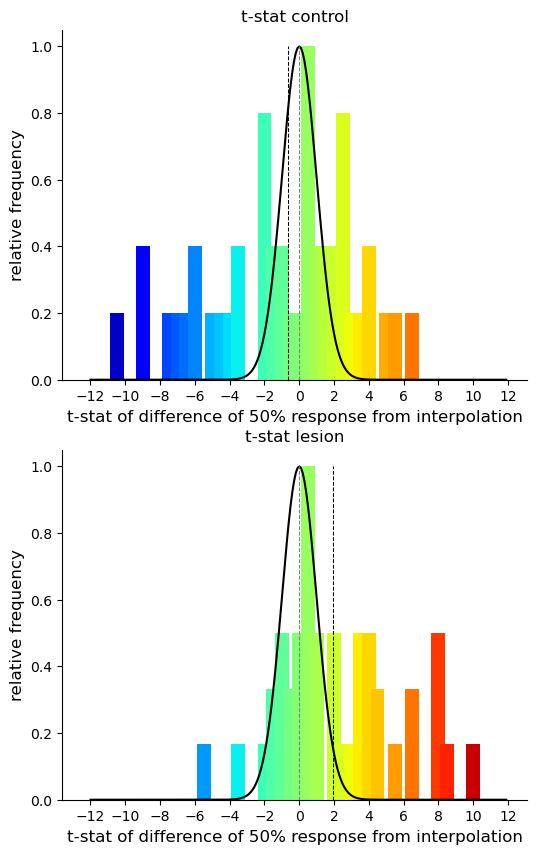

In [9]:
typeMedian = 'both'
indeces_resp = [loader_l.indeces_prob10,loader_l.indeces_prob50,loader_l.indeces_prob90]
responses = loader_l.cueResponses 
per_cell_l = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
responses  = loader_c.cueResponses 
per_cell_c = np.asarray([np.reshape(responses[:,ii,:],(responses.shape[0],-1))  for ii in indeces_resp])
c10_l, c50_l, c90_l = per_cell_l[0,:,:],per_cell_l[1,:,:],per_cell_l[2,:,:]
c10_c, c50_c, c90_c = per_cell_c[0,:,:],per_cell_c[1,:,:],per_cell_c[2,:,:]
c10, c50, c90 = per_cell_c[0,:,:],per_cell_c[1,:,:],per_cell_c[2,:,:]
cueKinkiness_c,kinkPvals_c,medNames_c = calculate_kinkiness(c10, c50, c90, typeMedian)
c10, c50, c90 = per_cell_l[0,:,:],per_cell_l[1,:,:],per_cell_l[2,:,:]
cueKinkiness_l,kinkPvals_l,medNames_l = calculate_kinkiness(c10, c50, c90, typeMedian)

x = np.arange(-12,12,0.1)
df = 100
type_kink = 1
fig,ax  =plt.subplots(2,1,figsize=(6,10))
vKinkiness  = [cueKinkiness_c[:,type_kink],cueKinkiness_l[:,type_kink]]
for iss in range(2):
    [ckhist, hcenters] = np.histogram(vKinkiness[iss], np.arange(-12,12,step=.5))
    ckhist = ckhist / max(ckhist)
    for ih in range(len(ckhist)):
        ax[iss].bar(hcenters[ih], ckhist[ih],color=cm.jet(ih/len(ckhist)))
    rr = stats.t(df)
    tpdfcurve = rr.pdf(x)
    tpdfcurve = tpdfcurve / max(tpdfcurve)
    ax[iss].plot(x, tpdfcurve, 'k-')
    ax[iss].plot([0, 0], [0, 1],color='grey',linestyle='--',linewidth=.75)
    ax[iss].plot(   [np.nanmean(vKinkiness[iss]),np.nanmean(vKinkiness[iss])],[0,1],color='black',linestyle='--',linewidth=.75)
    ax[iss].set_xticks(np.arange(-12,14,2))
    ax[iss].set_title('t-stat '+groups[iss])
    plot_config(ax[iss],'t-stat of difference of 50% response from interpolation','relative frequency',12,False)

#%% Monte carlo tests for t-statistic distribution 
type_kink = 1
vKinkiness  = [cueKinkiness_c[:,type_kink],cueKinkiness_l[:,type_kink]]
pvals_kinkiness = []
for  (ix,x) in enumerate(vKinkiness):
    res_std = compute_monte_carlo(x,statistic_std,int(len(x)),rvs_type = 'students-t',alternative='greater',batch =100)
    res_mean = compute_monte_carlo(x,statistic_mean,int(len(x)),rvs_type = 'students-t',alternative='greater',batch =100)
    res_mean_lo = compute_monte_carlo(x,statistic_mean,int(len(x)),rvs_type = 'students-t',alternative='less',batch =100)

    print([res_std.pvalue,res_mean.pvalue,])#res_median.pvalue])
    pvals_kinkiness.append([res_std.pvalue,res_mean.pvalue])#,res_median.pvalue])
    new_row =  pd.DataFrame({   'name_test':['MC_tstat_mean'],  'pvals':[res_mean.pvalue],'stats':[res_mean.statistic],
                                'stat_name': ['greater'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(x)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)

    new_row =  pd.DataFrame({   'name_test':['MC_tstat_mean'],  'pvals':[res_mean_lo.pvalue],'stats':[res_mean_lo.statistic],
                                'stat_name': ['lower'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(x)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)
    
    new_row =  pd.DataFrame({   'name_test':['MC_tstat_std'],  'pvals':[res_std.pvalue],'stats':[res_std.statistic],
                                    'stat_name': ['greater'],  'group_nb':[ix],'group_name':[ groups[ix]] ,'N':[len(x)]  })
    tests_pd = pd.concat([new_row,tests_pd.loc[:]]).reset_index(drop=True)

tests_pd
#%%  Test for t-stat between groups
type_kink = 1
groups_test =  [[cueKinkiness_c[:,type_kink],cueKinkiness_l[:,type_kink]]]
name_suff = ['50']
name_preff = 'tstat'
alternative = 'less'
tests_pd = get_tests_table(groups_test, name_preff, name_suff,restart_pd = False ,tests_pd=tests_pd,alternative=alternative)


# 1. Create the wrapper
fig_data_4e = FigureWithData(fig)

# 2. Save mean kinkiness per group (for bar plots or visualization)
vKinkiness = [cueKinkiness_c[:, type_kink], cueKinkiness_l[:, type_kink]]
kinkiness_means = np.array([np.nanmean(cueKinkiness_c[:, type_kink]), np.nanmean(cueKinkiness_l[:, type_kink])])
fig_data_4e.add_data("Kinkiness t-statistics (group means)", kinkiness_means, ['Control', 'Lesion'])

# 3. Save raw kinkiness data used for histograms
# kinkiness_individuals = np.column_stack((cueKinkiness_c[:, type_kink], cueKinkiness_l[:, type_kink]))
fig_data_4e.add_data("Kinkiness t-statistics (individual datapoints-Control)", cueKinkiness_c[:, type_kink], ['Control'])
fig_data_4e.add_data("Kinkiness t-statistics (individual datapoints-Lesion)", cueKinkiness_l[:, type_kink], [ 'Lesion'])

# 4. Save Monte Carlo stats
pvals_kink = np.asarray(pvals_kinkiness).flatten()
stat_array = np.column_stack((np.arange(len(pvals_kink)), pvals_kink))
stat_headers = ['Group_index', 'MonteCarlo_p_value']
fig_data_4e.add_stats("Monte Carlo tests kinkiness", stat_array, stat_headers)

# 5. Save
fig_data_4e.save(
    base_filename='figure_4e',
    folder_data=data_fig_dir,
    folder_figures=fig_dir
)


tests_pd.to_excel("analysis/stats/Fig4.xlsx")